# Testing UOT Computation time Cell Lines
Since the cell line data is much more dense than the immune cell data, UOT will take longer. In order to assess feasibility, we'll test a few comparisons at a time and extrapolate that to full comparisons.

## Imports

In [1]:
### Enabling fast reload ###
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and files ###
root = '../../../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Metadata/1mb_maxnorm_total_mass.csv'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Feasability'
save_dir

'../../../../../Generated Data/Single-to-single/sc_uot_ramani/Feasability'

In [3]:
### Imports ###
import sys
import os
import numpy as np
import pandas as pd
import cooler
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_ot_bulk_clr, get_cool_name
from time import perf_counter
from scipy.stats import pearsonr

In [4]:
### Pre-importing data ###
metadata_df = pd.read_csv(metadata_dir, index_col=0)
metadata_df

,cell_name,total_mass_95,total_mass_98,cell_line
0,cell231_HAP1_,938.503117,360.011112,HAP1
1,cell447_HAP1_,495.144885,289.556840,HAP1
2,cell470_HAP1_,490.376493,275.947577,HAP1
3,cell312_HAP1_,741.299690,328.747511,HAP1
4,cell29_HAP1_,883.559129,355.572255,HAP1
...,...,...,...,...
615,cell63_HeLa_,831.020976,352.527350,HeLa
616,cell54_HeLa_,833.285618,352.084282,HeLa
617,cell549_K562_,838.461384,350.797609,K562
618,cell219_HeLa_,869.111472,362.481811,HeLa


## Helper Functions

### Data generation and importing

In [7]:
def subset_clr_data(data_dir: str, metadata: pd.DataFrame, count: int=20, seed: int=42) -> list[cooler.Cooler]:
    '''
        Takes a directory of cooler files, selects the number of cells specified
        by count per cell line given in metadata.

        Function is specific to formatting in this notebook.

        Parameters
        ----------
        data_dir : str
            The path to the folder containing the data.
        metadata : pd.DataFrame
            Metadata dataframe providing a mapping for file to cell
            line.
        count : int
            Number of cells to import per cell line.
            Default = 20.
        seed : int
            Seed used for randomization
            Default = 42.

        Returns
        -------
        clrs_subset : list(cooler.Cooler)
            List of coolers from specified subset.
    '''
    # Selecting files
    sampled_files = (
        metadata.groupby('cell_line')
                .apply(lambda x: x.sample(
                    n=min(len(x), count),
                    replace=False,
                    random_state=seed
                ))
                .reset_index(drop=True)
    )
    samples = list(sampled_files["cell_name"])

    # Importing coolers
    clrs_subset = import_cool_dir(data_dir, include=samples)
    return clrs_subset

def long_transform(ot_data: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    '''
        Takes a file-to-file comparisons matrix with OT results and
        transforms these results into a long format, also providing
        row and column cell lines.

        Parameters
        ----------
        ot_data : pd.DataFrame
            File-to-file format OT results.
        metadata : pd.DataFrame
            Metadata providing the cell line per file name.
        
        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format dataframe additionally giving row and column
            cell lines.
    '''
    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_line"]

    # Long format
    ot_results_long = ot_data.reset_index().rename(columns={"index": "row_file"})
    ot_results_long = ot_results_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    
    # Mapping celltypes
    ot_results_long["row_cell_line"] = ot_results_long["row_file"].map(type_lookup)
    ot_results_long["col_cell_line"] = ot_results_long["col_file"].map(type_lookup)

    # Inter and intra
    ot_results_long["relationship"] = (
        ot_results_long["row_cell_line"] == ot_results_long["col_cell_line"]
        ).map({True: "intra", False: "inter"})

    return ot_results_long

def generate_ot_data(res: int=1, thres: int=95, reg_m: float = 10, count: int=20, 
                     seed: int=42) -> tuple[pd.DataFrame, float]:
    '''
        Generates pair-wise OT comparison data for the cell line data
        using the provided arguments. Additionally, keeps track of computation
        time.

        Function is specific to this notebook.

        Parameters
        ----------
        res : int
            Resolution to bin the data to in Mb.
            Default = 1.
        thres : int
            Threshold to use for the data.
            Default = 95.
        reg_m : float
            Unbalanced parameter to use.
            Default = 10.
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        seed : int
            Seed for subsetting
            Default = 42.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    # Subsetting
    clrs = subset_clr_data(data_dir, metadata_df, count, seed)
    
    # OT
        # Starting timer
    start_time = perf_counter()

        # Calculations
    ot_results = hic_ot_bulk_clr(clrs, clrs, chrom='chr1', res=res, thres=thres,
                                 thres_type='percentile', norm='max', unbalanced=reg_m)
    
        # Stopping timer
    end_time = perf_counter() - start_time

        # Saving results
    ot_results.to_csv(f'{save_dir}/CELL_LINES_unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv')

    # Transforming to long format
    ot_results_long = long_transform(ot_results, metadata_df)

    return ot_results_long, end_time

def load_ot_results_long(folder: str, res: int, thres: int, reg_m: float,
                         metadata: pd.DataFrame, count: int=20, seed: int=42) -> pd.DataFrame:
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        reg_m : float
            Unbalanced parameter used.
        metadata : pd.Dataframe
            Metadata providing the cell line per file name.
        count : int
            Number of cells used for analysis.
            Default = 20.
        seed : int
            Seed used to select data.
            Default = 42.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    # File
    file = f"{save_dir}/CELL_LINES_unbalanced_reg_m={reg_m}_cluster_{res}mb_{thres}_{count}_seed={seed}.csv"

    # Importing file
    ot_df = pd.read_csv(file, index_col=0)

    # Covert to long and concatenate
    ot_df_long = long_transform(ot_df, metadata)

    return ot_df_long

def load_method_results(path: str, count: int, seed: int=42) -> dict:
    '''
        Takes all OT results in the given path and compiles them
        into a list of flattened vectors.

        Parameters
        ----------
        path : str
            Path to OT results csv files.
        count : int
            Number of cells per cell type considered, selects specific
            datasets.
        seed : int
            Seed used to generate data, selects specific datasets.
            Default = 42.
        
        Returns
        -------
        methods : dict
            Dictionary of method results, accesible by metadata as 
            (res, thres, reg_m).
    '''
    dir = Path(path)
    methods = {}

    # Patterns
    pattern = re.compile(
        r"^CELL_LINES_unbalanced_reg_m=(?P<reg_m>\d+(?:\.\d+)?)_cluster_(?P<res>\d+)mb_(?P<thres>\d+)_(?P<count>\d+)_seed=(?P<seed>\d+)\.csv$"
    )

    for file in dir.glob("CELL_LINES_unbalanced_reg_m*.csv"):
        name = file.name
        p_match = pattern.match(name)
        match_count = int(p_match.group('count'))
        match_seed = int(p_match.group('seed'))

        if p_match and count == match_count and seed == match_seed:
            res = int(p_match.group('res'))
            thres = int(p_match.group('thres'))
            reg_m = float(p_match.group('reg_m'))
        
        else:
            continue
        
        # Save results to df
        df = pd.read_csv(file, index_col=0)
        
        # Convert to vector
        vec = df.to_numpy().ravel()

        # Add to methods registry
        method_id = (res, thres, reg_m)
        methods[method_id] = vec

    return methods

### Correspondence clustering

In [8]:
def calc_corr_matrix(methods: dict) -> pd.DataFrame:
    '''
        Computes the Pearson correlation coefficient between
        all OT methods, pairwise.

        Parameters
        ----------
        methods : dict
            Dictionary with all methods accessible via
            (res, thres, reg_m).

        Returns
        -------
        corr_df : df
            Dataframe for all pairwise comparisons between methods
    '''
    method_ids = list(methods.keys())
    n = len(method_ids)

    # Initialize empty df
    corr = np.zeros((n, n))

    # Loop through methods and indices to calculate r
    for i, mi in enumerate(method_ids):
        vi = methods[mi]

        for j, mj in enumerate(method_ids):
            if j < i:
                corr[i, j] = corr[j, i]
                continue
            
            r = pearsonr(vi, methods[mj])[0]
            corr[i, j] = corr[j, i] = r
    
    # Create dataframe
    corr_df = pd.DataFrame(
        corr,
        index=method_ids,
        columns=method_ids
    )

    return corr_df

## Generating Data

### Thres = 95

In [31]:
### Generating data for 95th percentile remove ###
results_95, time95 = generate_ot_data(1, 95, 10, 3, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_26086/874066475.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


cell547_K562_
['cell547_K562_', 'cell256_HeLa_', 'cell363_HeLa_', 'cell501_K562_', 'cell227_HAP1_', 'cell605_GM12878_', 'cell25_HeLa_', 'cell571_GM12878_', 'cell514_K562_', 'cell502_GM12878_', 'cell373_HAP1_', 'cell381_HAP1_']


### Thres = 98

In [35]:
### Generating data for 98th percentile remove ###
results_98, time98 = generate_ot_data(1, 98, 10, 3, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_26086/874066475.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


cell547_K562_
['cell547_K562_', 'cell256_HeLa_', 'cell363_HeLa_', 'cell501_K562_', 'cell227_HAP1_', 'cell605_GM12878_', 'cell25_HeLa_', 'cell571_GM12878_', 'cell514_K562_', 'cell502_GM12878_', 'cell373_HAP1_', 'cell381_HAP1_']


### Thres = 99

In [36]:
### Generating data for 99th percentile remove ###
results_99, time99 = generate_ot_data(1, 99, 10, 3, 42)

/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_26086/874066475.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


cell547_K562_
['cell547_K562_', 'cell256_HeLa_', 'cell363_HeLa_', 'cell501_K562_', 'cell227_HAP1_', 'cell605_GM12878_', 'cell25_HeLa_', 'cell571_GM12878_', 'cell514_K562_', 'cell502_GM12878_', 'cell373_HAP1_', 'cell381_HAP1_']


### Bulk Generating
Here, we'll generate comparisons when selecting 2 cells from each cell line, giving us 2^4 = 16 comparisons. We'll compute this for a subset of thresholds and resolutions to assess feasibility and correspondence between methods.

In [ ]:
### Generating data for varying thresholds and resolutions ###
    # Setting parameters
res_list = [4, 2, 1]
thres_list = [90, 95, 98]

    # Performing OT
for res in res_list:
    for thres in thres_list:
        print(f'Starting OT for res={res}, thres={thres}.')
        
        # OT
        results, time = generate_ot_data(res, thres, 10, 2, 42)

        # Updating time file
        time_path = f"{save_dir}/{time_file}"

            # Cast to strings to ensure proper indexing
        res_str = str(res)
        thres_str = str(thres)

            # Make or import csv
        if os.path.exists(time_path):
            df_calc = pd.read_csv(time_path, index_col=0)
            df_calc.index = df_calc.index.astype(str)
        else:
            df_calc = pd.DataFrame()

            # Insert value in row
        df_calc.at[thres_str, res_str] = time

            # Save to CSV
        df_calc.to_csv(time_path)

        print(f'Finished OT for res={res}, thres={thres} in {time} seconds')

Starting OT for res=4, thres=90.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=4, thres=90 in 4.3737707500004035 seconds
Starting OT for res=4, thres=95.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=4, thres=95 in 0.7335812090004765 seconds
Starting OT for res=4, thres=98.
Finished OT for res=4, thres=98 in 0.15782879199832678 seconds
Starting OT for res=2, thres=90.


...

Finished OT for res=1, thres=90 in 1107.0089102499987 seconds
Starting OT for res=1, thres=95.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=1, thres=95 in 190.21065712500058 seconds
Starting OT for res=1, thres=98.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=1, thres=98 in 18.515740499999083 seconds


In [10]:
### Calculating exceptions ###
exception_list = [
    (8, 90), 
    (8, 95),
    (2, 99),
    (1, 99)
]

for (res, thres) in exception_list:
    print(f'Starting OT for res={res}, thres={thres}.')
        
    # OT
    results, time = generate_ot_data(res, thres, 10, 2, 42)

    # Updating time file
    time_path = f"{save_dir}/{time_file}"

        # Cast to strings to ensure proper indexing
    res_str = str(res)
    thres_str = str(thres)

        # Make or import csv
    if os.path.exists(time_path):
        df_calc = pd.read_csv(time_path, index_col=0)
        df_calc.index = df_calc.index.astype(str)
    else:
        df_calc = pd.DataFrame()

        # Insert value in row
    df_calc.at[thres_str, res_str] = time

        # Save to CSV
    df_calc.to_csv(time_path)

    print(f'Finished OT for res={res}, thres={thres} in {time} seconds')

Starting OT for res=8, thres=90.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=8, thres=90 in 0.4654209170003014 seconds
Starting OT for res=8, thres=95.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=8, thres=95 in 0.24454558399884263 seconds
Starting OT for res=2, thres=99.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=2, thres=99 in 0.2380294579998008 seconds
Starting OT for res=1, thres=99.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/1182109427.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=1, thres=99 in 4.794107625000834 seconds


In [54]:
### Calculating expensive comparisons ###
expensive_exceptions = [
    (8, 85),
    (4, 85),
    (2, 85),
    (1, 85)
]

for (res, thres) in expensive_exceptions:
    print(f'Starting OT for res={res}, thres={thres}.')
        
    # OT
    results, time = generate_ot_data(res, thres, 10, 2, 42)

    # Updating time file
    time_path = f"{save_dir}/{time_file}"

        # Cast to strings to ensure proper indexing
    res_str = str(res)
    thres_str = str(thres)

        # Make or import csv
    if os.path.exists(time_path):
        df_calc = pd.read_csv(time_path, index_col=0)
        df_calc.index = df_calc.index.astype(str)
    else:
        df_calc = pd.DataFrame()

        # Insert value in row
    df_calc.at[thres_str, res_str] = time

        # Save to CSV
    df_calc.to_csv(time_path)

    print(f'Finished OT for res={res}, thres={thres} in {time} seconds\n')

Starting OT for res=8, thres=85.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/319808185.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=8, thres=85 in 0.67073608300052 seconds

Starting OT for res=4, thres=85.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/319808185.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=4, thres=85 in 6.011021624999557 seconds

Starting OT for res=2, thres=85.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/319808185.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


Finished OT for res=2, thres=85 in 108.38847162499951 seconds

Starting OT for res=1, thres=85.


/var/folders/pf/6xtc7fx5435c3f0dbwrdl5tc0000gn/T/ipykernel_27118/319808185.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


: 

1 mb at 85% does not seem to work. Thus, we'll try to rerun that specific comparison until it runs

In [ ]:
time_file = '/CELL_LINES_16_comparisons_times.csv'
thres = 87
res = 1
print(f'Starting OT for res=1, thres={thres}.')

# OT
results, time = generate_ot_data(1, thres, 10, 2, 42)

# Updating time file
time_path = f"{save_dir}/{time_file}"

    # Cast to strings to ensure proper indexing
res_str = str(res)
thres_str = str(thres)

    # Make or import csv
if os.path.exists(time_path):
    df_calc = pd.read_csv(time_path, index_col=0)
    df_calc.index = df_calc.index.astype(str)
else:
    df_calc = pd.DataFrame()

    # Insert value in row
df_calc.at[thres_str, res_str] = time

    # Save to CSV
df_calc.to_csv(time_path)

print(f'Finished OT for res=1, thres={thres} in {time} seconds\n')

Starting OT for res=1, thres=87.
Finished OT for res=1, thres=87 in 1863.048955833001 seconds



## Comparing Data

In [15]:
### Importing data ###
methods_dict = load_method_results(save_dir, 2)
times_df = pd.read_csv(f"{save_dir}/CELL_LINES_16_comparisons_times.csv", index_col=0)
times_df = times_df.sort_index(ascending=False)

### Calculation times

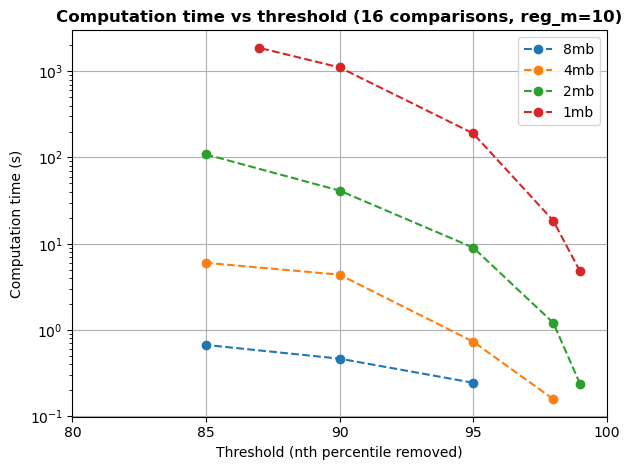

In [22]:
### Plotting calculation times
    # Initializing figure
plt.figure()

    # Looping through resolutions and thresholds
for res in times_df.columns:
    series = times_df[res].dropna()

    plt.plot(series.index, series.values, label=f"{res}mb", marker="o", linestyle='--')

    # Further formatting
plt.xlabel("Threshold (nth percentile removed)")
plt.ylabel("Computation time (s)")
plt.title(f"Computation time vs threshold (16 comparisons, reg_m=10)", fontweight='bold')
plt.legend()
plt.grid(True)
plt.yscale("log")
plt.xlim(left=80, right=100)
plt.xticks([80, 85, 90, 95, 100])
plt.tight_layout()

### Correspondence

In [23]:
### Calculating Pearson Correlation ###
corr_df = calc_corr_matrix(methods_dict)

<Figure size 800x600 with 0 Axes>

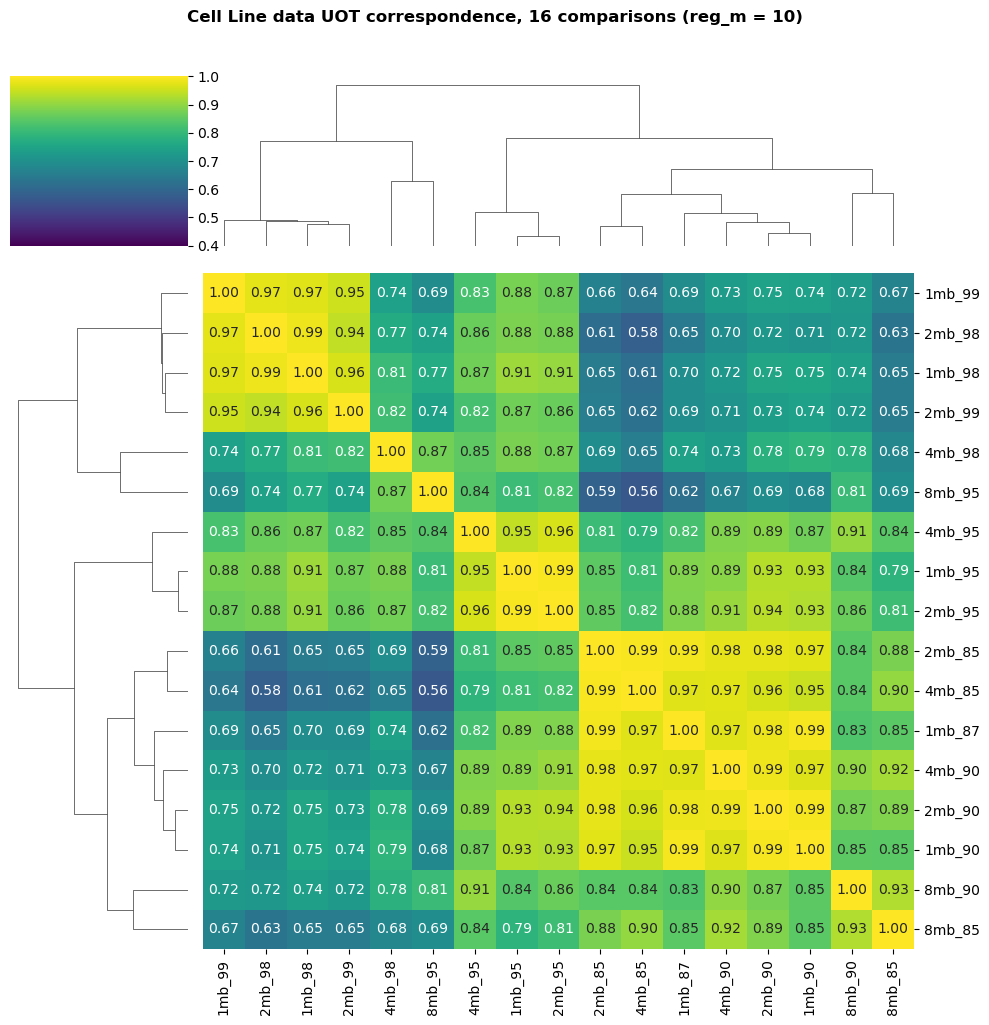

In [24]:
### Visualizing correlation matrix ###
    # Filter method IDs for this group
method_ids = methods_dict.keys()

# Generate readable labels
labels = [f"{mid[0]}mb_{mid[1]}" for mid in method_ids]

plt.figure(figsize=(8, 6))
sns.clustermap(
    corr_df,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0.4,
    vmax=1
)
title = "Cell Line data UOT correspondence, 16 comparisons (reg_m = 10)"
plt.suptitle(title, y=1.02, fontweight='bold')
plt.tight_layout()

It seems that, for this dataset, thresholds seems to be more leading than resolution. That could be due to the data being denser, meaning that averaging is more effective than in the previous dataset.